# Security filters · 4. After the day

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ula-uab/lscm-decision-making/blob/main/cases/security_filters/notebooks/04_after_the_day.ipynb)

The day has passed and the arrivals at the filters were counted. How good were the demand scenarios as forecasts, and what would each lane policy have given with the real demand?

**The observed curve is invented.** The real counts are not available, so the script `tools/generate_observed.py` simulates every passenger with "true" assumptions that the scenarios do not know exactly.

In [1]:
# In Google Colab, install the package from GitHub (it takes a few seconds).
# On your own computer, install the repository environment instead (see README).
import sys
if "google.colab" in sys.modules:
    %pip install -q "git+https://github.com/ula-uab/lscm-decision-making#subdirectory=cases/security_filters"

In [2]:
import pandas as pd
import security_filters as sf
from security_filters.plots import plot_curves, plot_policy

schedule = sf.read_schedule()
day = sf.examples.DAY
flights = sf.flights_for_curve(schedule, day)
profiles = sf.profile_library()
curves = sf.demand_curves(sf.examples.demand_scenarios(), flights, profiles)
policies = sf.examples.lane_policies(curves)
observed = sf.read_observed(day)
print(f"Observed passengers: {observed.sum()}")

Observed passengers: 66619


## 1. Scenarios against the observed curve

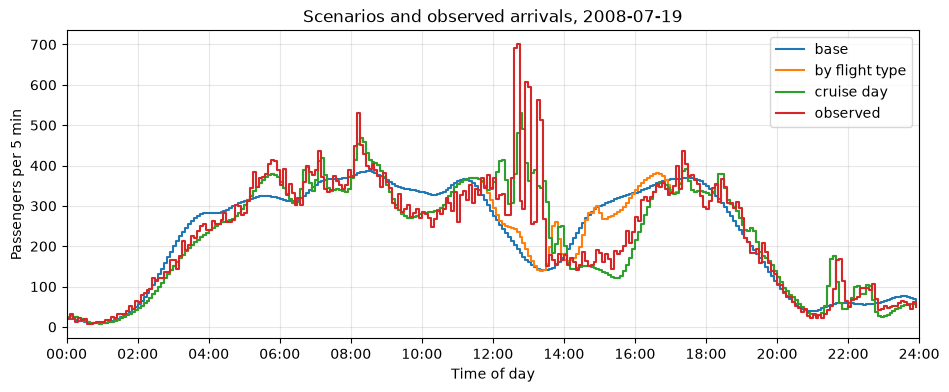

In [3]:
plot_curves({**{name: curves[name] for name in curves}, "observed": observed},
            title=f"Scenarios and observed arrivals, {day}");

Forecast errors by hour, with the measures used for demand forecasts (error = observed − forecast; a positive bias means the scenario fell short):

In [4]:
sf.compare_forecasts(curves, observed).round(2)

,MAE,MAPE,bias,max_abs_error,total_forecast,total_observed
base,469.45,0.19,39.41,2249.74,65673.21,66619.0
by flight type,334.73,0.14,53.13,1932.13,65343.85,66619.0
cruise day,146.51,0.08,53.13,588.28,65343.85,66619.0


## 2. The policies with the observed demand

In [5]:
all_curves = pd.concat([curves, observed], axis=1)
sf.decision_table(policies, all_curves, "max_wait_min").round(1)

scenario,lane_hours,base,by flight type,cruise day,observed
policy,,,,,
flat 28,600.0,10.6,1.6,2.9,8.1
plan for base,443.0,27.2,40.7,40.7,33.2
plan for by flight type,464.0,7.4,14.3,14.3,16.6
plan for cruise day,462.0,7.4,16.3,14.3,11.4


In [6]:
sf.evaluate_all(policies, observed.to_frame()).set_index("policy")[
    ["lane_hours", "max_queue", "time_of_max_queue", "max_wait_min", "average_wait_min"]].round(1)

,lane_hours,max_queue,time_of_max_queue,max_wait_min,average_wait_min
policy,,,,,
flat 28,600.0,679.0,13:00,8.1,0.5
plan for base,443.0,1363.0,13:20,33.2,2.6
plan for by flight type,464.0,1198.0,13:20,16.6,1.5
plan for cruise day,462.0,890.0,13:20,11.4,1.4


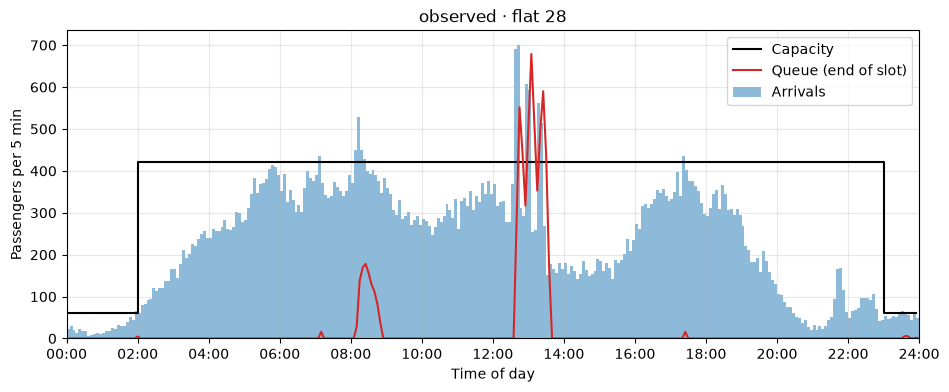

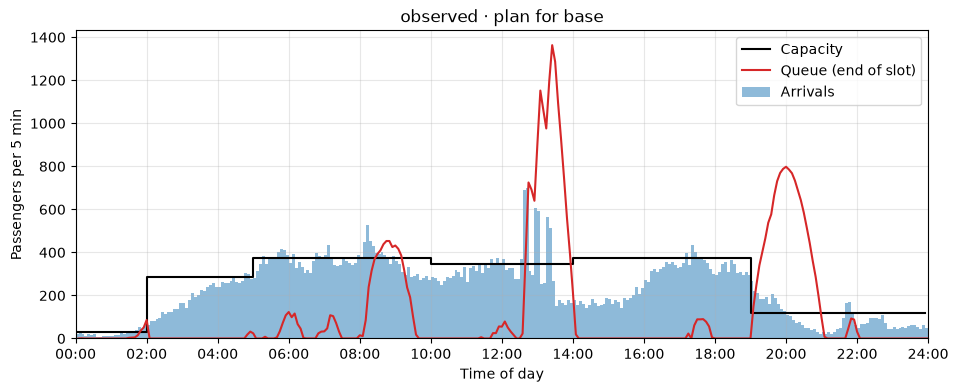

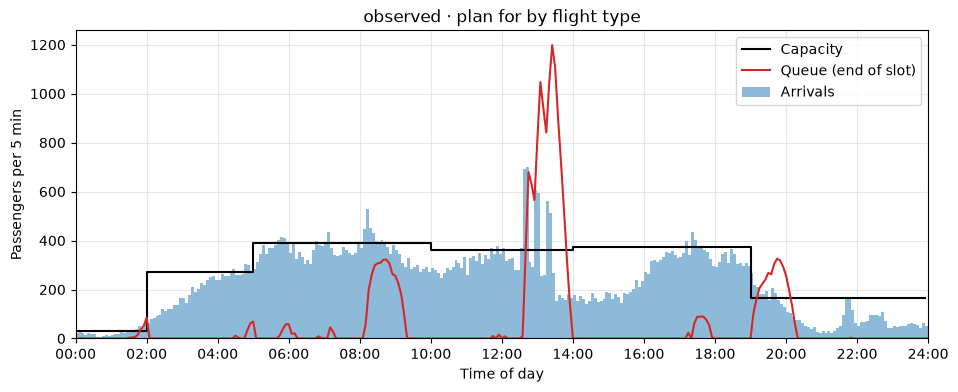

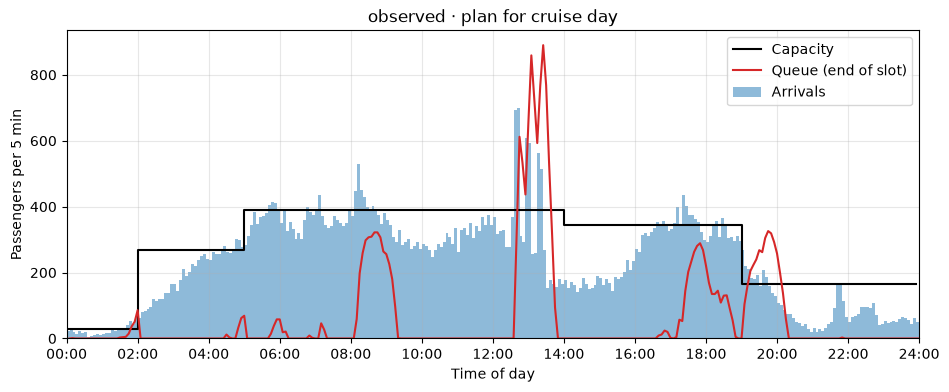

In [7]:
for p in policies:
    plot_policy(observed, p)

## 3. Questions

- Which scenario was the best forecast? Is it also the one whose policy worked best?
- Where in the day are the largest errors, and which assumption explains them?
- Knowing what happened, would you change the policy you chose in notebook 3? Would you change the scenarios for the next similar day?